# Model Evaluation

## 1. Goal

We compare the final advanced model with the original simple architecture: how well they recover a **16-bit message**, how much they change the image, and what happens after an attack. Training details are in [02_simple_architecture_training.ipynb](02_simple_architecture_training.ipynb) and [03_advanced_architecture_training.ipynb](03_advanced_architecture_training.ipynb).

## 2. Models and Data

Both checkpoints use the same **500 test images**, preprocessing to 128 x 128 pixels, fixed messages, and seed 95. The advanced checkpoint is the locked final model. The simple message-only checkpoint had the lowest validation BER among the recorded simple runs; it already failed the 30 dB image-quality target and serves as a weak baseline. Neither checkpoint is selected or adjusted using the test results.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import get_dataloaders
from src.evaluate import evaluate_scenarios, load_models
from src.message_metrics import logits_to_bits
from src.noise import apply_attack
from src.utils import SEED

cache_dir = PROJECT_ROOT / 'notebooks' / 'evaluation'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
checkpoints = {
    'Simple': PROJECT_ROOT / 'results/simple-clean-16bit-v1/checkpoints/message-only/best_model.pt',
    'Advanced': PROJECT_ROOT / 'results/checkpoints/different-architecture-robust-fused-decoder/best_model.pt',
}
models = {name: load_models(path, device) for name, path in checkpoints.items()}
_, _, test_loader = get_dataloaders(
    PROJECT_ROOT / 'data', PROJECT_ROOT / 'data/splits.json',
    batch_size=16, num_workers=0, shuffle_train=False,
)
assert test_loader is not None and len(test_loader.dataset) == 500
assert all(config['message_length'] == 16 for _, _, config in models.values())
fixed_messages = torch.randint(
    0, 2, (500, 16), dtype=torch.float32,
    generator=torch.Generator().manual_seed(SEED),
)
example_index = 0
visual_cases = [(0, 'noise-0.05'), (1, 'blur-5-1.0'), (2, 'downscale-0.50')]
print(f'Device: {device} | Test images: {len(test_loader.dataset)} | Message: 16 bits')

Device: cuda | Test images: 500 | Message: 16 bits


In [3]:
scenarios = {
    'clean': [],
    'noise-0.01': [{'name': 'gaussian_noise', 'std': 0.01}],
    'noise-0.03': [{'name': 'gaussian_noise', 'std': 0.03}],
    'noise-0.05': [{'name': 'gaussian_noise', 'std': 0.05}],
    'blur-3-0.5': [{'name': 'gaussian_blur', 'kernel_size': 3, 'sigma': 0.5}],
    'blur-5-1.0': [{'name': 'gaussian_blur', 'kernel_size': 5, 'sigma': 1.0}],
    'downscale-0.75': [{'name': 'downscale', 'scale_factor': 0.75}],
    'downscale-0.50': [{'name': 'downscale', 'scale_factor': 0.5}],
    'rotation-minus-2': [{'name': 'rotation', 'angle': -2.0}],
    'rotation-plus-2': [{'name': 'rotation', 'angle': 2.0}],
    'rotation-minus-5': [{'name': 'rotation', 'angle': -5.0}],
    'rotation-plus-5': [{'name': 'rotation', 'angle': 5.0}],
}

## 3. One Image, One Message

Test image **0** is fixed in advance and receives the same message for both models. The absolute difference is multiplied by 10 and clipped to [0, 1], using the same scale for both rows.

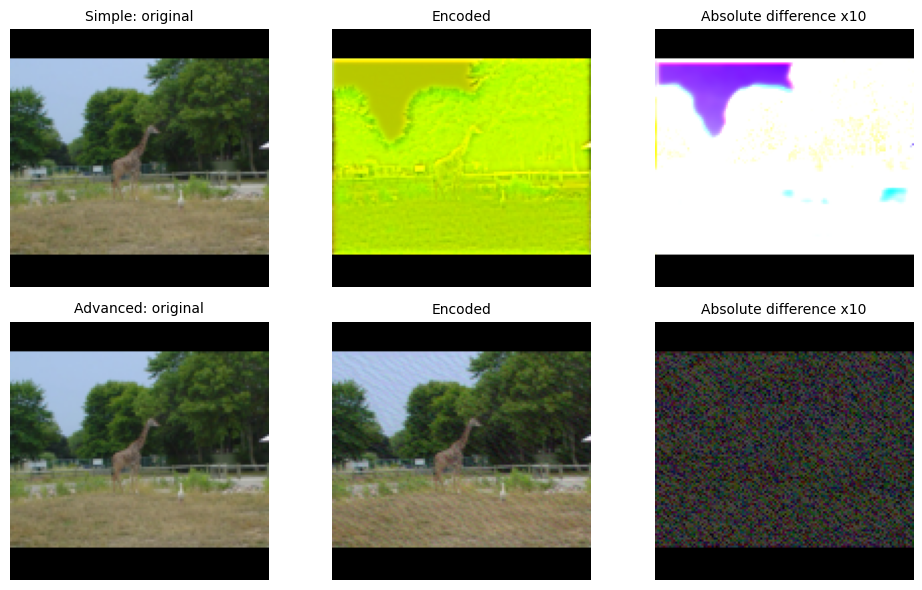

,Original message,Decoded message,Wrong bits
Model,,,
Simple,0110010010101010,1011101000101010,7
Advanced,0110010010101010,0110010010101010,0


In [4]:
def bit_string(bits):
    return ''.join(str(int(bit)) for bit in bits.detach().cpu().flatten())

def show_image(axis, tensor, title):
    image_array = tensor.detach().cpu().squeeze(0).permute(1, 2, 0).clamp(0, 1)
    axis.imshow(image_array)
    axis.set_title(title, fontsize=10)
    axis.axis('off')

assert test_loader is not None
image, mask = test_loader.dataset[example_index]
image, mask = image.unsqueeze(0).to(device), mask.unsqueeze(0).to(device)
message = fixed_messages[example_index:example_index + 1].to(device)
figure, axes = plt.subplots(2, 3, figsize=(10, 6))
example_records = []
with torch.inference_mode():
    for row, (name, (encoder, decoder, _)) in enumerate(models.items()):
        encoded = encoder(image, message, mask)
        decoded = logits_to_bits(decoder(encoded, mask))
        show_image(axes[row, 0], image, f'{name}: original')
        show_image(axes[row, 1], encoded, 'Encoded')
        show_image(axes[row, 2], 10 * (encoded - image).abs(), 'Absolute difference x10')
        example_records.append({
            'Model': name, 'Original message': bit_string(message),
            'Decoded message': bit_string(decoded),
            'Wrong bits': int((decoded != message.bool()).sum().item()),
        })
figure.tight_layout()
plt.show()
display(pd.DataFrame(example_records).set_index('Model'))

The image difference and the bit errors answer different questions: preserving appearance does not by itself guarantee correct decoding. This is one fixed example; the next table measures all 500 images.

## 4. Results Without Attacks

**BER** is the fraction of wrong bits; **exact accuracy** is the fraction of messages with all 16 bits correct. **PSNR and SSIM compare original and encoded image content before any attack**, with pixel values in [0, 1] and padding excluded.


In [5]:
RECOMPUTE_TEST_RESULTS = False
metric_columns = ['ber', 'exact_accuracy', 'psnr', 'ssim']
result_frames = []
for name, (encoder, decoder, config) in models.items():
    cache_path = cache_dir / f'{name.lower()}_test.csv'
    if name == 'Advanced' and not cache_path.exists() and not RECOMPUTE_TEST_RESULTS:
        raise FileNotFoundError('The saved advanced_test.csv is required; no test was rerun.')
    if cache_path.exists() and not RECOMPUTE_TEST_RESULTS:
        model_results = pd.read_csv(cache_path)
    else:
        print(f'Evaluating {name}: 500 images, {len(scenarios)} scenarios...', flush=True)
        records = evaluate_scenarios(
            encoder, decoder, test_loader, device, scenarios,
            message_length=16, seed=SEED, fixed_messages=fixed_messages,
        )
        model_results = pd.DataFrame(records)[['scenario'] + metric_columns]
        if not cache_path.exists():
            model_results.to_csv(cache_path, index=False, mode='x')
    assert model_results['scenario'].tolist() == list(scenarios)
    result_frames.append(model_results.assign(model=name))
results = pd.concat(result_frames, ignore_index=True)

In [6]:
clean_results = results.loc[results['scenario'] == 'clean'].set_index('model')
display(clean_results[metric_columns].rename(columns={
    'ber': 'BER', 'exact_accuracy': 'Exact accuracy',
    'psnr': 'PSNR (dB)', 'ssim': 'SSIM',
}).round(6))
advanced_clean = clean_results.loc['Advanced']
simple_clean = clean_results.loc['Simple']
display(Markdown(
    f"The advanced model recovers **{advanced_clean['exact_accuracy']:.1%}** of complete messages "
    f"without attacks, at **{advanced_clean['psnr']:.2f} dB** PSNR. "
    f"The simple baseline has BER **{simple_clean['ber']:.4f}** and PSNR "
    f"**{simple_clean['psnr']:.2f} dB**; both decoding and image quality matter."
))

,BER,Exact accuracy,PSNR (dB),SSIM
model,,,,
Simple,0.289125,0.000,7.633795,0.437764
Advanced,0.000875,0.988,33.645167,0.906757


The advanced model recovers **98.8%** of complete messages without attacks, at **33.65 dB** PSNR. The simple baseline has BER **0.2891** and PSNR **7.63 dB**; both decoding and image quality matter.

## 5. Resistance to Attacks

Each scenario processes all 500 test images with the same messages. Noise strength is its standard deviation, blur labels give kernel size and sigma, downscaling gives the scale factor before resizing back, and rotation angles are in degrees. The table measures **decoding after the attack**; it does not measure the visual damage caused by that attack.

ber           exact_accuracy       
model             Advanced    Simple       Advanced Simple
scenario                                                  
noise-0.01        0.001000  0.289750          0.986    0.0
noise-0.03        0.002625  0.290375          0.964    0.0
noise-0.05        0.013750  0.292000          0.834    0.0
blur-3-0.5        0.001000  0.288375          0.986    0.0
blur-5-1.0        0.039375  0.288750          0.522    0.0
downscale-0.75    0.010625  0.289375          0.850    0.0
downscale-0.50    0.116750  0.289875          0.134    0.0
rotation-minus-2  0.001500  0.289250          0.978    0.0
rotation-plus-2   0.001750  0.289000          0.984    0.0
rotation-minus-5  0.006125  0.290375          0.912    0.0
rotation-plus-5   0.002750  0.290000          0.964    0.0

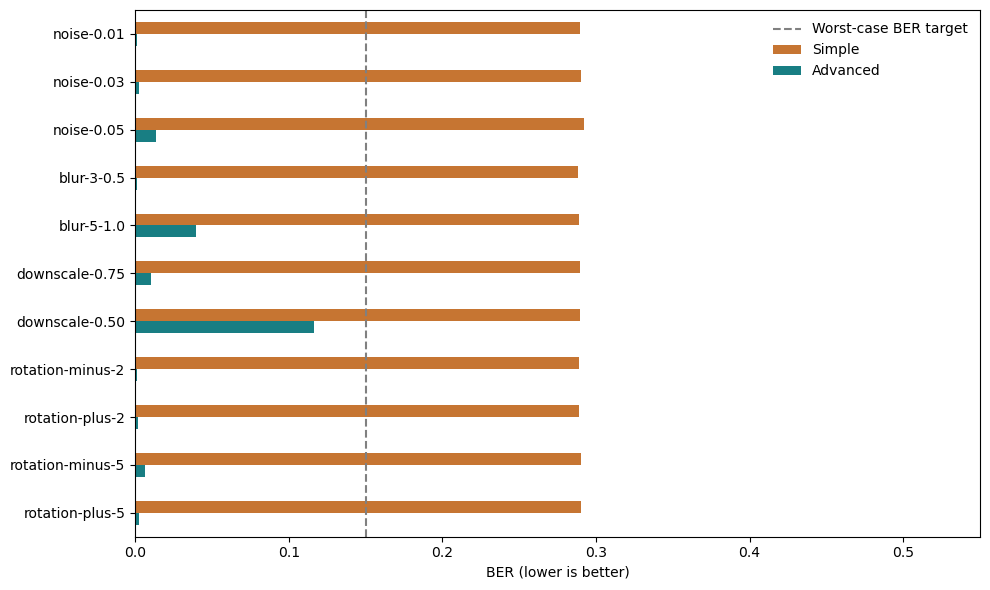

In [7]:
attacked_results = results.loc[results['scenario'] != 'clean']
attack_order = [name for name in scenarios if name != 'clean']
attack_table = attacked_results.pivot(
    index='scenario', columns='model', values=['ber', 'exact_accuracy'],
).reindex(attack_order)
display(attack_table.round(6))
ber_table = attacked_results.pivot(index='scenario', columns='model', values='ber')
ber_table = ber_table.reindex(index=attack_order, columns=['Simple', 'Advanced'])
figure, axis = plt.subplots(figsize=(10, 6))
ber_table.plot.barh(ax=axis, color=['#c67532', '#187e83'])
axis.axvline(0.15, color='gray', linestyle='--', label='Worst-case BER target')
axis.set(xlabel='BER (lower is better)', ylabel='', xlim=(0, 0.55))
axis.invert_yaxis()
axis.legend(frameon=False)
figure.tight_layout()
plt.show()

These examples use the fixed test indices **0, 1 and 2**, with noise, strong blur and downscaling to half size. Both models receive the same seeded attack for each image; these illustrations are not selected by success and do not replace the full-test averages.

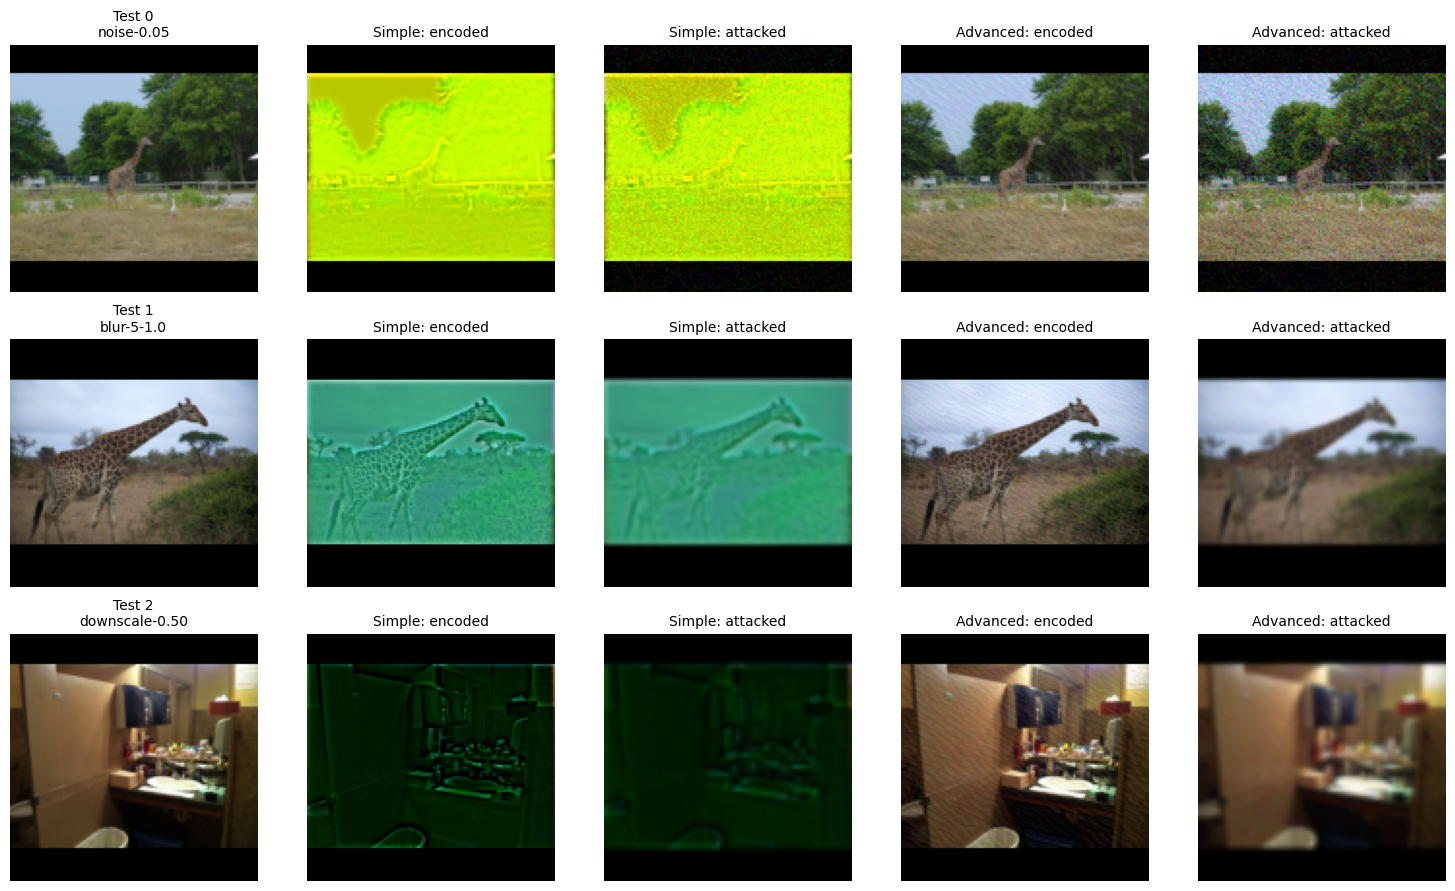

,Index,Model,Attack,Original,Before,After,Wrong before,Wrong after
0,0,Simple,noise-0.05,0110010010101010,1011101000101010,1011101000101010,7,7
1,0,Advanced,noise-0.05,0110010010101010,0110010010101010,0110010010101010,0,0
2,1,Simple,blur-5-1.0,0101011101110101,1111101101110101,1111101111110101,4,5
3,1,Advanced,blur-5-1.0,0101011101110101,0101011101110101,0101011101110101,0,0
4,2,Simple,downscale-0.50,0010011001000010,0110101111000011,0110101111000011,6,6
5,2,Advanced,downscale-0.50,0010011001000010,0010011001000010,0010011011000010,0,1


In [8]:
assert test_loader is not None
figure, axes = plt.subplots(len(visual_cases), 5, figsize=(15, 9))
attack_example_records = []
with torch.inference_mode():
    for row, (sample_index, scenario) in enumerate(visual_cases):
        image, mask = test_loader.dataset[sample_index]
        image, mask = image.unsqueeze(0).to(device), mask.unsqueeze(0).to(device)
        message = fixed_messages[sample_index:sample_index + 1].to(device)
        show_image(axes[row, 0], image, f'Test {sample_index}\n{scenario}')
        for model_index, (name, (encoder, decoder, _)) in enumerate(models.items()):
            encoded = encoder(image, message, mask)
            decoded_before = logits_to_bits(decoder(encoded, mask))
            torch.manual_seed(SEED + sample_index)
            attacked, attacked_mask = apply_attack(encoded, mask, scenarios[scenario][0])
            decoded_after = logits_to_bits(decoder(attacked, attacked_mask))
            show_image(axes[row, 1 + 2 * model_index], encoded, f'{name}: encoded')
            show_image(axes[row, 2 + 2 * model_index], attacked, f'{name}: attacked')
            attack_example_records.append({
                'Index': sample_index, 'Model': name, 'Attack': scenario,
                'Original': bit_string(message), 'Before': bit_string(decoded_before),
                'After': bit_string(decoded_after),
                'Wrong before': int((decoded_before != message.bool()).sum().item()),
                'Wrong after': int((decoded_after != message.bool()).sum().item()),
            })
figure.tight_layout()
plt.show()
display(pd.DataFrame(attack_example_records))

## 6. Conclusion

In [9]:
advanced_attacks = attacked_results.loc[attacked_results['model'] == 'Advanced']
worst_attack = advanced_attacks.loc[advanced_attacks['ber'].idxmax()]
display(Markdown(
    f"The advanced model combines **{advanced_clean['psnr']:.2f} dB** PSNR and "
    f"**{advanced_clean['ssim']:.4f}** SSIM with an average attacked BER of "
    f"**{advanced_attacks['ber'].mean():.4f}**. Its hardest evaluated attack is "
    f"**{worst_attack['scenario']}**: BER **{worst_attack['ber']:.4f}**, but only "
    f"**{worst_attack['exact_accuracy']:.1%}** of complete messages are recovered. "
    "Low average bit error therefore does not guarantee reliable recovery of every message."
))

The advanced model combines **33.65 dB** PSNR and **0.9068** SSIM with an average attacked BER of **0.0179**. Its hardest evaluated attack is **downscale-0.50**: BER **0.1168**, but only **13.4%** of complete messages are recovered. Low average bit error therefore does not guarantee reliable recovery of every message.